# **Step 1: Install Required Libraries**

In [2]:
# Install essential libraries (most of these are already available in Colab)
!pip install imbalanced-learn
!pip install matplotlib seaborn scikit-learn

# **Step 2: Import Libraries**

In [3]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# **Step 3: Load and Explore the Dataset**

# **Step 3A: Mount the Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 3B: Load and Explore the Dataset**

In [5]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Dataset/creditcard.csv")  # Adjust path if needed

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Step 4: Dataset Overview and Class Imbalance Check**

In [6]:
# Dataset structure
print("Shape of dataset:", df.shape)

Shape of dataset: (284807, 31)


In [7]:
# Summary of dataset
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [8]:
# Check if any missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
# Distribution of target variable
print("\nClass Distribution:")
print(df['Class'].value_counts())


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


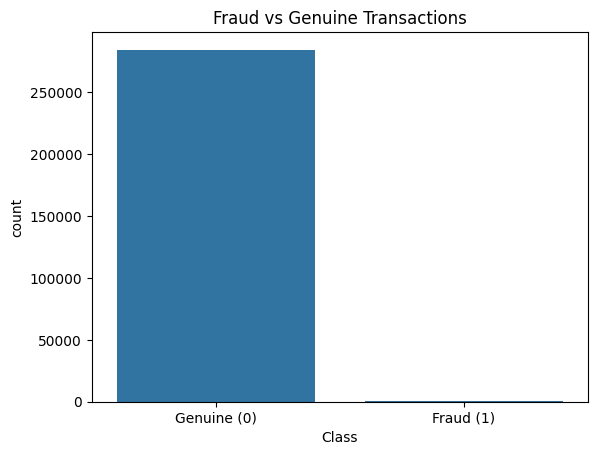

In [10]:
# Visualize class imbalance
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Genuine Transactions')
plt.xticks([0, 1], ['Genuine (0)', 'Fraud (1)'])
plt.show()

# **Step 5: Data Preprocessing**

In [11]:
from sklearn.preprocessing import StandardScaler

# Drop 'Time' column
df = df.drop(['Time'], axis=1)

# Normalize the 'Amount' column
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Split the dataset into features and labels
X = df.drop(['Class'], axis=1)
y = df['Class']

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (227845, 29)
Test set shape: (56962, 29)


# **Step 6: Handle Class Imbalance using SMOTE**

In [12]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Original training class distribution:")
print(y_train.value_counts())

print("\nResampled training class distribution:")
print(y_train_res.value_counts())

Original training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Resampled training class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


# **Step 7: Model 1 – Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize and train logistic regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



In [14]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Confusion Matrix:
 [[55355  1509]
 [    8    90]]


In [15]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_lr))

Accuracy Score: 0.9733682103858713


In [16]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_lr))

ROC-AUC Score: 0.9459151731880147


# **Step 8: Model 2 – Random Forest Classifier**

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Confusion Matrix:
 [[56852    12]
 [   17    81]]


In [19]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))

Accuracy Score: 0.9994908886626171


# **Step 9: Deep Learning Model (Keras Neural Network)**

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the model architecture
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_res, y_train_res, epochs=10, batch_size=2048, validation_split=0.2)

# Predict on test data
y_pred_dl_prob = model.predict(X_test)
y_pred_dl = (y_pred_dl_prob > 0.5).astype(int)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_dl))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7475 - loss: 0.5295 - val_accuracy: 0.8998 - val_loss: 0.1798
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9521 - loss: 0.1290 - val_accuracy: 0.9372 - val_loss: 0.1286
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9648 - loss: 0.0908 - val_accuracy: 0.9607 - val_loss: 0.0927
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9716 - loss: 0.0744 - val_accuracy: 0.9728 - val_loss: 0.0728
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9758 - loss: 0.0633 - val_accuracy: 0.9795 - val_loss: 0.0591
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9794 - loss: 0.0539 - val_accuracy: 0.9867 - val_loss: 0.0445
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9823 - loss: 0.0470 - val_accuracy: 0.9909 - val_loss: 0.0353
Epoch 8/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9852 - loss: 0.0412 - val_accuracy:

In [21]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))

Confusion Matrix:
 [[56545   319]
 [   11    87]]


In [22]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_dl))

Accuracy Score: 0.9942066640918507


In [23]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_dl))

ROC-AUC Score: 0.9410726129224903


# **Step 10: Compare Models & Save the Best Model**

In [24]:
import joblib

# Save model
joblib.dump(rf_model, '/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/rf_fraud_detection_model.pkl')
print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [26]:
import joblib

# Save Logistic Regression
joblib.dump(lr_model, '/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/logistic_regression_model.pkl')

# Save Deep Learning model
model.save('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/deep_learning_model.keras')

print("All models saved successfully!")

All models saved successfully!


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


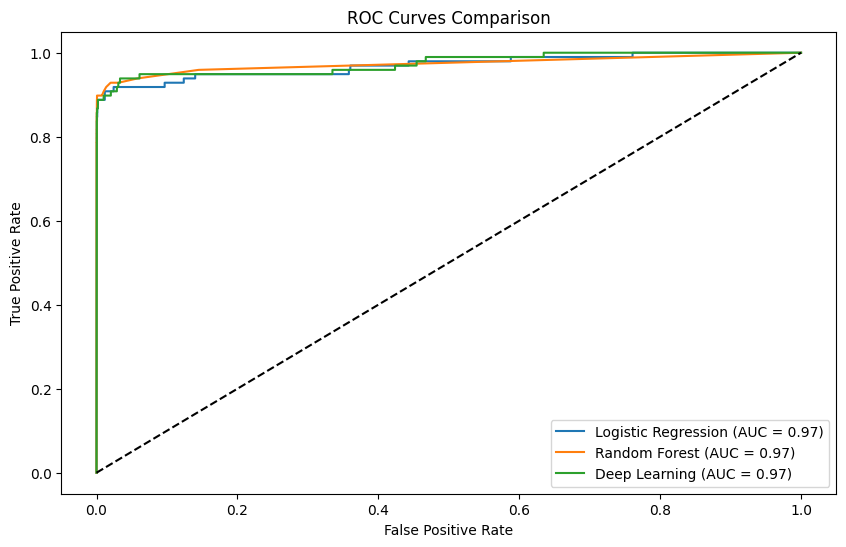

In [27]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict probabilities for ROC curves
y_prob_lr = lr_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_dl = model.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_dl, tpr_dl, _ = roc_curve(y_test, y_prob_dl)
roc_auc_dl = auc(fpr_dl, tpr_dl)

# Plot ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_dl, tpr_dl, label=f'Deep Learning (AUC = {roc_auc_dl:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


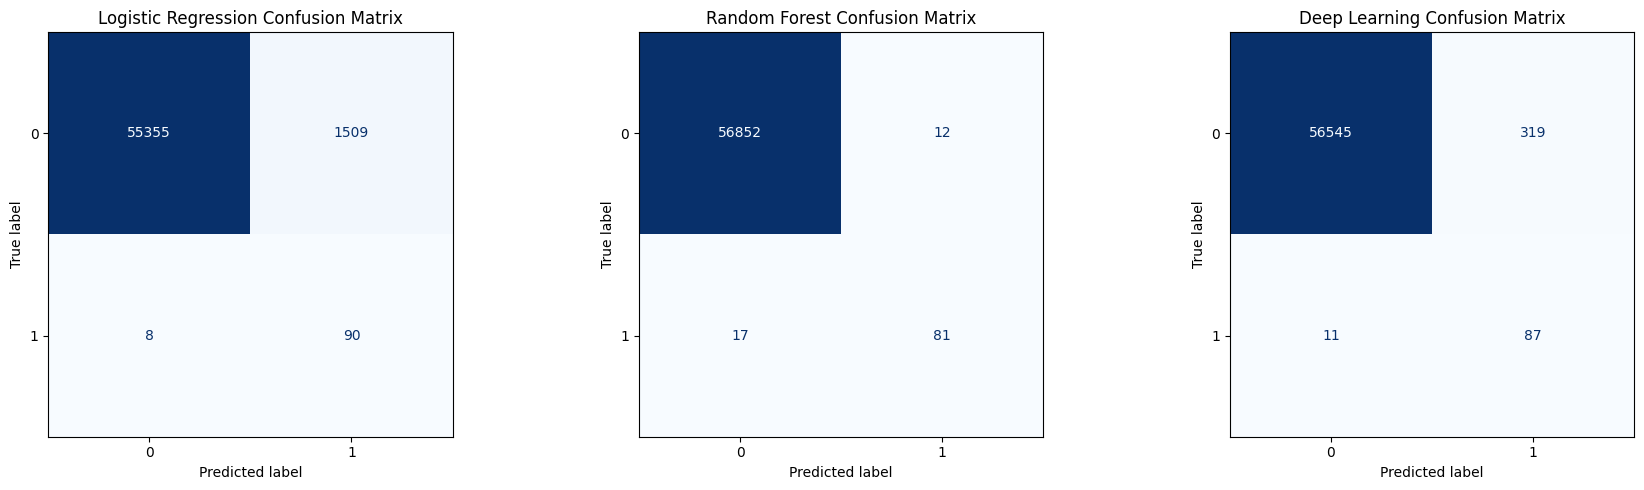

In [28]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'Deep Learning': None}
preds = {
    'Logistic Regression': lr_model.predict(X_test),
    'Random Forest': rf_model.predict(X_test),
    'Deep Learning': (model.predict(X_test) > 0.5).astype(int).ravel()
}

for ax, (name, y_pred) in zip(axes, preds.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

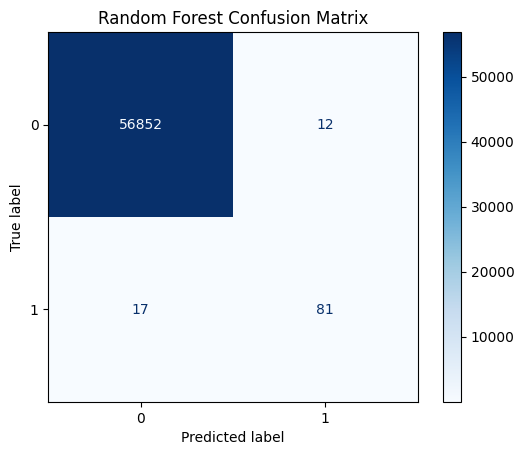

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

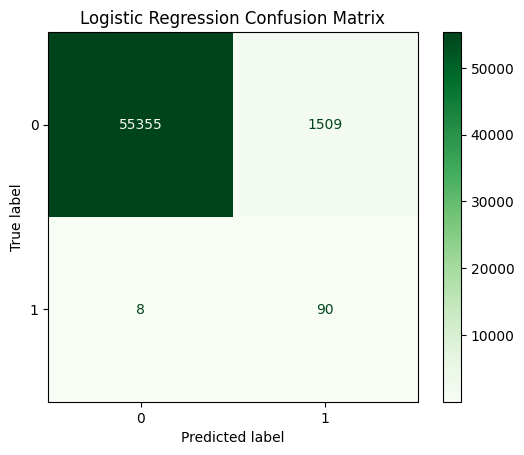

In [30]:
# Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

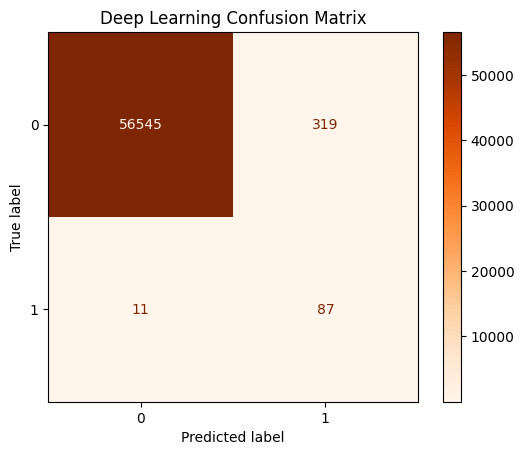

In [31]:
# Confusion Matrix for Deep Learning
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl, cmap='Oranges')
plt.title('Deep Learning Confusion Matrix')
plt.show()

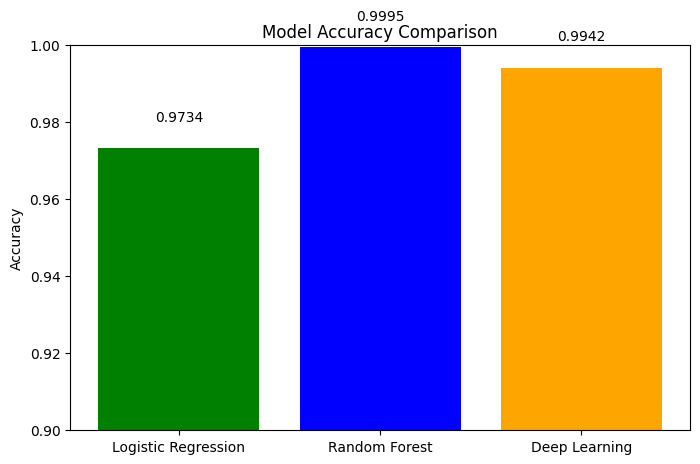

In [39]:
# Accuracy comparison bar graph
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Deep Learning': accuracy_score(y_test, y_pred_dl)
}

plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color=['green', 'blue', 'orange'])
plt.ylim([0.9, 1.0])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.007, f"{v:.4f}", ha='center')  # Increased gap from 0.002 to 0.005

plt.show()

In [53]:
# Suppress TensorFlow retracing warnings (optional)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Error only
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import joblib
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd

# === Load saved models ===
lr_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/logistic_regression_model.pkl')
rf_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/rf_fraud_detection_model.pkl')
dl_model_loaded = load_model('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/deep_learning_model.h5')

# === Feature columns (same as training) ===
feature_columns = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                   'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                   'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

# === Sample transaction with 29 features ===
sample_transaction = np.array([[-1.359807, -0.072781, 2.536347, 1.378155, -0.338321, 0.462388,
                                0.239599, 0.098698, 0.363787, 0.090531, -0.551599, -0.617800,
                                -0.991390, -0.311169, 1.468177, -0.470401, 0.207971, 0.025790,
                                0.403993, 0.251412, -0.018307, 0.277838, -0.110474, 0.066928,
                                0.128539, -0.189115, 0.133558, -0.021053, 149.62]])

# Convert to DataFrame for sklearn models
sample_df = pd.DataFrame(sample_transaction, columns=feature_columns)

# === Logistic Regression Prediction ===
lr_prob = lr_model_loaded.predict_proba(sample_df)[:, 1][0]
lr_pred = lr_model_loaded.predict(sample_df)[0]

# === Random Forest Prediction ===
rf_prob = rf_model_loaded.predict_proba(sample_df)[:, 1][0]
rf_pred = rf_model_loaded.predict(sample_df)[0]

# === Deep Learning Prediction ===
dl_prob = dl_model_loaded.predict(sample_transaction)[0][0]
dl_pred = int(dl_prob > 0.5)

# === Final Output ===
print(" Predictions for Sample Transaction\n")
print(f" Logistic Regression Prediction: {lr_pred} | Probability: {lr_prob:.4f}")
print(f" Random Forest Prediction:       {rf_pred} | Probability: {rf_prob:.4f}")
print(f" Deep Learning Prediction:       {dl_pred} | Probability: {dl_prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
 Predictions for Sample Transaction

 Logistic Regression Prediction: 1 | Probability: 1.0000
 Random Forest Prediction:       0 | Probability: 0.0100
 Deep Learning Prediction:       0 | Probability: 0.0000


In [63]:
# === Suppress TensorFlow warnings ===
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# === Import required libraries ===
import joblib
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd

# === Load the trained models ===
lr_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/logistic_regression_model.pkl')
rf_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/rf_fraud_detection_model.pkl')
dl_model_loaded = load_model('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/deep_learning_model.h5')

# === Define feature columns used in training ===
feature_columns = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                   'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                   'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

# === Sample transaction (29 features) ===
sample_transaction = np.array([[-1.359807, -0.072781, 2.536347, 1.378155, -0.338321, 0.462388,
                                0.239599, 0.098698, 0.363787, 0.090531, -0.551599, -0.617800,
                                -0.991390, -0.311169, 1.468177, -0.470401, 0.207971, 0.025790,
                                0.403993, 0.251412, -0.018307, 0.277838, -0.110474, 0.066928,
                                0.128539, -0.189115, 0.133558, -0.021053, 149.62]])

sample_df = pd.DataFrame(sample_transaction, columns=feature_columns)

# === Logistic Regression Prediction ===
lr_prob = lr_model_loaded.predict_proba(sample_df)[:, 1][0]
lr_pred = lr_model_loaded.predict(sample_df)[0]
lr_status = " Safe Transaction" if lr_pred == 0 else "❗️Alert: Fraudulent Transaction"

# === Random Forest Prediction ===
rf_prob = rf_model_loaded.predict_proba(sample_df)[:, 1][0]
rf_pred = rf_model_loaded.predict(sample_df)[0]
rf_status = " Safe Transaction" if rf_pred == 0 else "❗️Alert: Fraudulent Transaction"

# === Deep Learning Prediction ===
dl_prob = dl_model_loaded.predict(sample_transaction)[0][0]
dl_pred = int(dl_prob > 0.5)
dl_status = " Safe Transaction" if dl_pred == 0 else "❗️Alert: Fraudulent Transaction"

# === Majority Voting for Final Verdict ===
votes = [lr_pred, rf_pred, dl_pred]
fraud_votes = votes.count(1)
final_verdict = " Final Verdict: Safe Transaction" if fraud_votes < 2 else "❗️Final Verdict: Fraudulent Transaction"

# === Display the Results ===
print("\n Predictions for Sample Transaction\n")
print(f" Logistic Regression:  {lr_status} | Probability of Fraud: {lr_prob:.4f}")
print(f" Random Forest:        {rf_status} | Probability of Fraud: {rf_prob:.4f}")
print(f" Deep Learning (ANN):  {dl_status} | Probability of Fraud: {dl_prob:.4f}")
print("\n " + final_verdict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

 Predictions for Sample Transaction

 Logistic Regression:  ❗️Alert: Fraudulent Transaction | Probability of Fraud: 1.0000
 Random Forest:         Safe Transaction | Probability of Fraud: 0.0100
 Deep Learning (ANN):   Safe Transaction | Probability of Fraud: 0.0000

  Final Verdict: Safe Transaction


In [65]:
import pandas as pd

# Replace the path below with your actual dataset path in Google Drive
data = pd.read_csv('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Dataset/creditcard.csv')

# Check dataset loaded successfully
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [71]:
# Get 5 random fraudulent transactions from dataset
fraud_samples = data[data['Class'] == 1].sample(n=5, random_state=42)

# Check the sampled fraud transactions
print(fraud_samples[feature_columns + ['Class']])

               V1         V2         V3         V4         V5        V6  \
17407  -29.200329  16.155701 -30.013712   6.476731 -21.225810 -4.902997   
12369  -18.018561  10.558600 -24.667741  11.786180 -10.564657 -2.645681   
143333  -7.030308   3.421991  -9.525072   5.270891  -4.024630 -2.865682   
149357  -1.855061   1.554964  -1.405809   0.669327  -0.280230  1.178652   
15225  -19.856322  12.095893 -22.464083   6.115541 -15.148022 -4.346724   

               V7         V8        V9        V10  ...       V21       V22  \
17407  -19.791248  19.168327 -3.617242  -7.870122  ...  1.809371 -2.175815   
12369  -18.023468   2.693655 -6.219464 -12.744761  ... -2.319479  0.908839   
143333  -6.989195   3.791551 -4.622730  -8.409665  ...  1.103398 -0.541855   
149357  -3.459979  -2.815155  1.242229  -4.156354  ... -0.095308  0.946629   
15225  -15.648507  13.276805 -3.974162  -8.859194  ...  1.750730 -1.409636   

             V23       V24       V25       V26       V27       V28  Amount  \
17

In [75]:
# === Suppress TensorFlow warnings ===
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# === Import required libraries ===
import joblib
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd

# === Load the trained models ===
lr_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/logistic_regression_model.pkl')
rf_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/rf_fraud_detection_model.pkl')
dl_model_loaded = load_model('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/deep_learning_model.h5')

# === Define feature columns used in training ===
feature_columns = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                   'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                   'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

# === Sample transaction (29 features) ===
sample_transaction = np.array([[-29.200329, 16.155701, -30.013712, 6.476731, -21.225810, -4.902997,
                               -19.791248, 19.168327, -3.617242, -7.870122, 1.051137, -5.434328,
                               -2.900434, -6.742172, 1.039781, -3.091914, -3.061950, 0.048661,
                               2.042262, 0.116785, 1.809371, -2.175815, -1.365104, 0.174286,
                               2.103868, -0.209944, 1.278681, 0.372393, 99.99]])

# Convert to DataFrame for sklearn models
sample_df = pd.DataFrame(sample_transaction, columns=feature_columns)

# === Logistic Regression Prediction ===
lr_prob = lr_model_loaded.predict_proba(sample_df)[:, 1][0]
lr_pred = lr_model_loaded.predict(sample_df)[0]
lr_status = "Safe Transaction" if lr_pred == 0 else "❗️Alert: Fraudulent Transaction"

# === Random Forest Prediction ===
rf_prob = rf_model_loaded.predict_proba(sample_df)[:, 1][0]
rf_pred = rf_model_loaded.predict(sample_df)[0]
rf_status = "Safe Transaction" if rf_pred == 0 else "❗️Alert: Fraudulent Transaction"

# === Deep Learning Prediction ===
dl_prob = dl_model_loaded.predict(sample_transaction)[0][0]
dl_pred = int(dl_prob > 0.5)
dl_status = "Safe Transaction" if dl_pred == 0 else "❗️Alert: Fraudulent Transaction"

# === Average Probability and Final Verdict ===
avg_prob = (lr_prob + rf_prob + dl_prob) / 3
threshold = 0.3  # Adjustable threshold: tweak to be more/less sensitive

final_verdict = "❗️Final Verdict: Fraudulent Transaction" if avg_prob > threshold else "Final Verdict: Safe Transaction"

# === Display the Results ===
print("\n Predictions for Sample Transaction\n")
print(f" Logistic Regression:  {lr_status} | Probability of Fraud: {lr_prob:.4f}")
print(f" Random Forest:        {rf_status} | Probability of Fraud: {rf_prob:.4f}")
print(f" Deep Learning (ANN):  {dl_status} | Probability of Fraud: {dl_prob:.4f}")
print(f"\n Average Fraud Probability: {avg_prob:.4f}")
print("\n " + final_verdict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

 Predictions for Sample Transaction

 Logistic Regression:  ❗️Alert: Fraudulent Transaction | Probability of Fraud: 1.0000
 Random Forest:        ❗️Alert: Fraudulent Transaction | Probability of Fraud: 0.6300
 Deep Learning (ANN):  Safe Transaction | Probability of Fraud: 0.0000

 Average Fraud Probability: 0.5433

 ❗️Final Verdict: Fraudulent Transaction


In [80]:
import pandas as pd
import joblib

# Load dataset (make sure path is correct)
data = pd.read_csv('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Dataset/creditcard.csv')

# Feature columns used in training
feature_columns = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                   'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                   'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

# Load trained Random Forest model
rf_model_loaded = joblib.load('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Models/rf_fraud_detection_model.pkl')

# Prepare features for prediction
X = data[feature_columns]

# Predict classes using RF
data['RF_Prediction'] = rf_model_loaded.predict(X)

# Print first 1000 rows of actual class vs predicted
print(data[['Class', 'RF_Prediction']].head(1000))

# Optional: Save results with predictions to new CSV
data.to_csv('/content/drive/MyDrive/B.Tech Projects/CSE/LAPBCS001/AI-Based Fraud Detection System for Online Transactions with Real-Time Alerts/Results/rf_predictions.csv', index=False)

print("Predictions completed and saved successfully.")

     Class  RF_Prediction
0        0              0
1        0              0
2        0              0
3        0              0
4        0              0
..     ...            ...
995      0              0
996      0              0
997      0              0
998      0              0
999      0              0

[1000 rows x 2 columns]
Predictions completed and saved successfully.
